# Feature Engineering, Modeling, Explainability, Fairness

Builds on the cleaned dataset from `01_eda_cleaning.ipynb`.

1. Feature engineering: payment trend, utilization ratio, credit-limit-to-income proxy
2. Train/test split
3. Logistic regression baseline vs XGBoost
4. Model comparison (AUC, precision, recall)
5. SHAP explainability
6. Fairness check across age/gender groups
7. Deploy recommendation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import shap

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42

In [2]:
df = pd.read_csv('../data/default_credit_card_clean.csv')
df.shape

(30000, 25)

## Feature engineering

The `PAY_0..PAY_6` columns run most-recent (`PAY_0`) to oldest (`PAY_6`).
Chronological order (oldest to newest) is `PAY_6, PAY_5, PAY_4, PAY_3, PAY_2, PAY_0`.

- **pay_trend**: slope of a straight line fit through the six repayment status
  values in chronological order. Positive means repayment status is getting
  worse (more delayed) over time; negative means improving.
- **avg_utilization**: mean of `BILL_AMTx / LIMIT_BAL` across the six months.
  Clipped to [0, 3] since a handful of accounts carry a bill larger than their
  limit (over-limit balances), and unbounded ratios would distort the mean.
- **credit_limit_to_income_proxy**: this dataset has no income field. As a
  proxy for repayment capacity, average monthly payment amount
  (`mean(PAY_AMT1..PAY_AMT6)`) stands in for income. This is a real
  limitation, not a substitute for actual income data, and is called out
  again in the final write-up.

In [3]:
pay_cols_chronological = ['PAY_6', 'PAY_5', 'PAY_4', 'PAY_3', 'PAY_2', 'PAY_0']
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

x_idx = np.arange(len(pay_cols_chronological))

def slope(row_values):
    return np.polyfit(x_idx, row_values, 1)[0]

df['pay_trend'] = df[pay_cols_chronological].apply(slope, axis=1)

util = df[bill_cols].div(df['LIMIT_BAL'].replace(0, np.nan), axis=0)
df['avg_utilization'] = util.clip(lower=0, upper=3).mean(axis=1)

avg_pay_amt = df[pay_amt_cols].mean(axis=1)
df['credit_limit_to_income_proxy'] = df['LIMIT_BAL'] / (avg_pay_amt + 1)

df[['pay_trend', 'avg_utilization', 'credit_limit_to_income_proxy']].describe()

,pay_trend,avg_utilization,credit_limit_to_income_proxy
count,3.000000e+04,30000.000000,30000.000000
mean,5.210762e-02,0.373117,9088.778722
std,2.271455e-01,0.350000,47925.637107
min,-1.542857e+00,0.000000,0.411907
25%,-1.590241e-17,0.030286,22.788777
50%,0.000000e+00,0.285026,38.272527
75%,1.428571e-01,0.688432,88.543831
max,1.285714e+00,3.000000,710000.000000


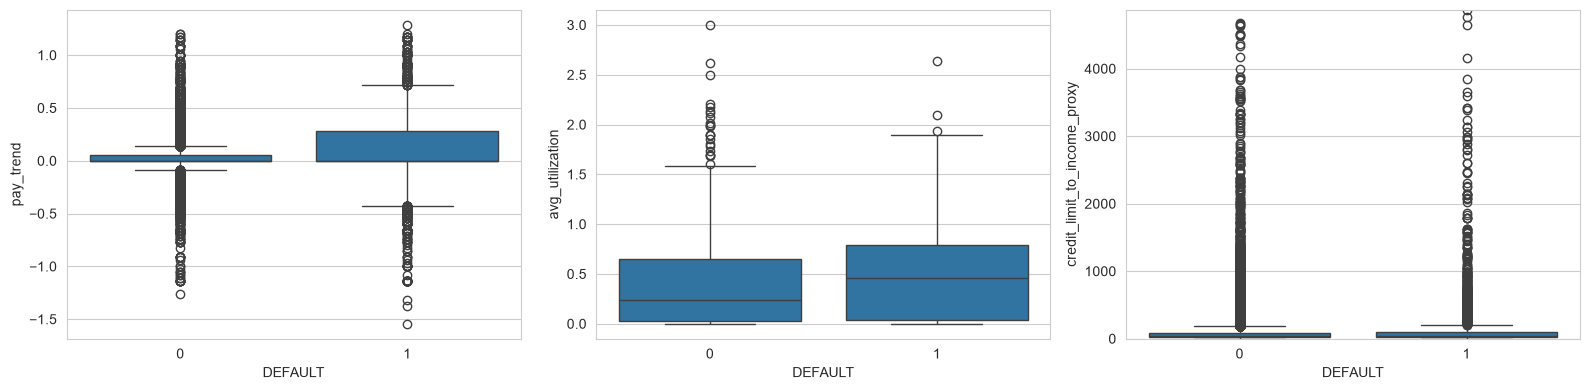

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=df, x='DEFAULT', y='pay_trend', ax=axes[0])
sns.boxplot(data=df, x='DEFAULT', y='avg_utilization', ax=axes[1])
sns.boxplot(data=df, x='DEFAULT', y='credit_limit_to_income_proxy', ax=axes[2])
axes[2].set_ylim(0, df['credit_limit_to_income_proxy'].quantile(0.95))
plt.tight_layout()

## Train / test split

In [5]:
feature_cols = [c for c in df.columns if c not in ('ID', 'DEFAULT')]
X = df[feature_cols]
y = df['DEFAULT']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train.shape, X_test.shape

((24000, 26), (6000, 26))

## Logistic regression baseline

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)

logreg_proba = logreg.predict_proba(X_test_scaled)[:, 1]
logreg_pred = logreg.predict(X_test_scaled)

print('AUC:', roc_auc_score(y_test, logreg_proba))
print(classification_report(y_test, logreg_pred))

AUC: 0.7221786365613294
              precision    recall  f1-score   support

           0       0.87      0.73      0.79      4673
           1       0.39      0.61      0.48      1327

    accuracy                           0.70      6000
   macro avg       0.63      0.67      0.63      6000
weighted avg       0.76      0.70      0.72      6000



## XGBoost

In [7]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=RANDOM_STATE,
)
xgb.fit(X_train, y_train)

xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_pred = xgb.predict(X_test)

print('AUC:', roc_auc_score(y_test, xgb_proba))
print(classification_report(y_test, xgb_pred))

AUC: 0.775771959392176
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      4673
           1       0.47      0.61      0.54      1327

    accuracy                           0.76      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.76      0.77      6000



## Model comparison

In [8]:
comparison = pd.DataFrame({
    'model': ['Logistic Regression', 'XGBoost'],
    'auc': [roc_auc_score(y_test, logreg_proba), roc_auc_score(y_test, xgb_proba)],
    'precision': [precision_score(y_test, logreg_pred), precision_score(y_test, xgb_pred)],
    'recall': [recall_score(y_test, logreg_pred), recall_score(y_test, xgb_pred)],
    'f1': [f1_score(y_test, logreg_pred), f1_score(y_test, xgb_pred)],
})
comparison

,model,auc,precision,recall,f1
0,Logistic Regression,0.722179,0.390513,0.614167,0.477446
1,XGBoost,0.775772,0.474389,0.614167,0.535304


In [9]:
comparison.to_csv('../docs/model_comparison.csv', index=False)

## SHAP explainability (XGBoost)

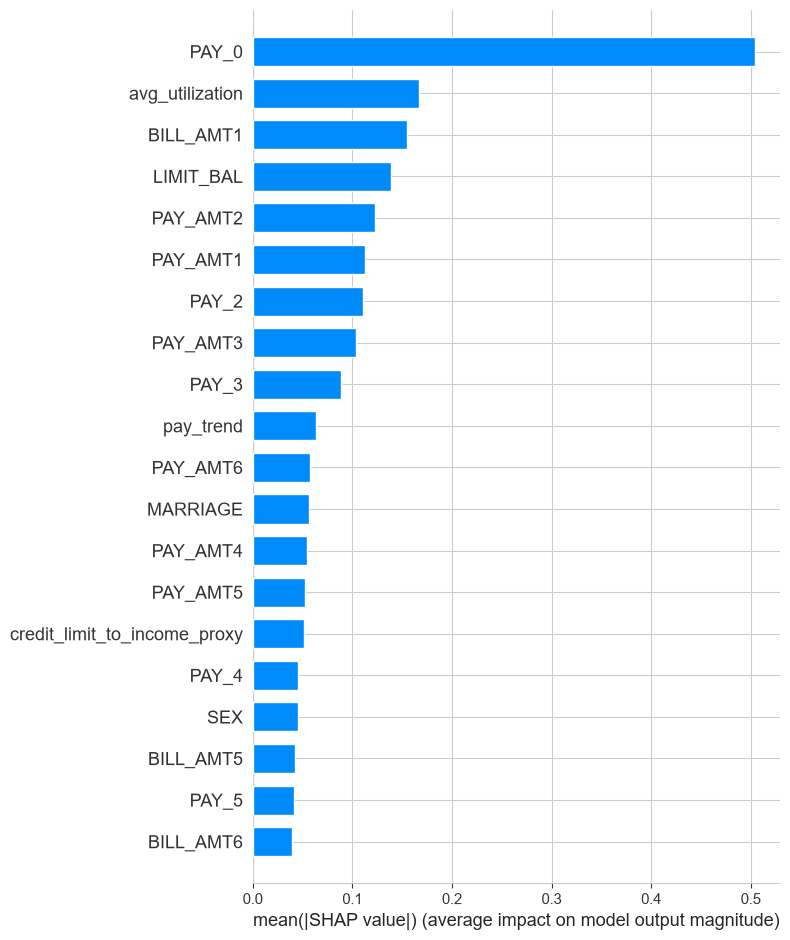

In [10]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('../docs/shap_global_importance.png', dpi=150)
plt.show()

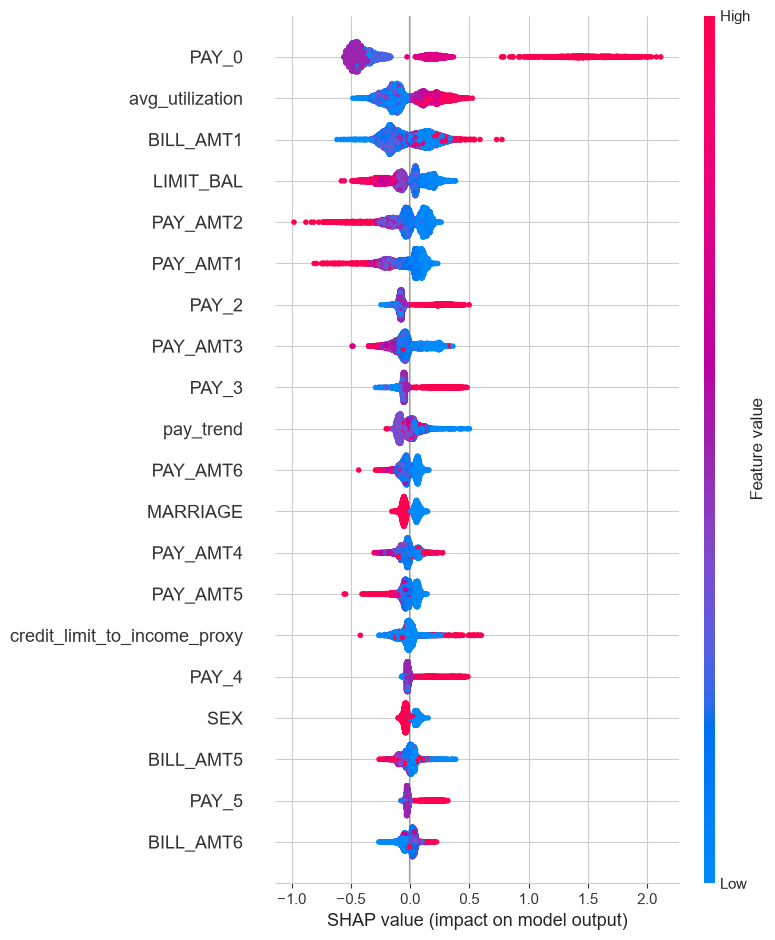

In [11]:
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../docs/shap_summary.png', dpi=150)
plt.show()

In [12]:
mean_abs_shap = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
mean_abs_shap.to_csv('../docs/shap_feature_importance.csv', index=False)
mean_abs_shap.head(15)

,feature,mean_abs_shap
5,PAY_0,0.504168
24,avg_utilization,0.167431
11,BILL_AMT1,0.155314
0,LIMIT_BAL,0.138428
18,PAY_AMT2,0.122586
17,PAY_AMT1,0.112411
6,PAY_2,0.110758
19,PAY_AMT3,0.103287
7,PAY_3,0.088761
23,pay_trend,0.063073


### Individual prediction explanation example

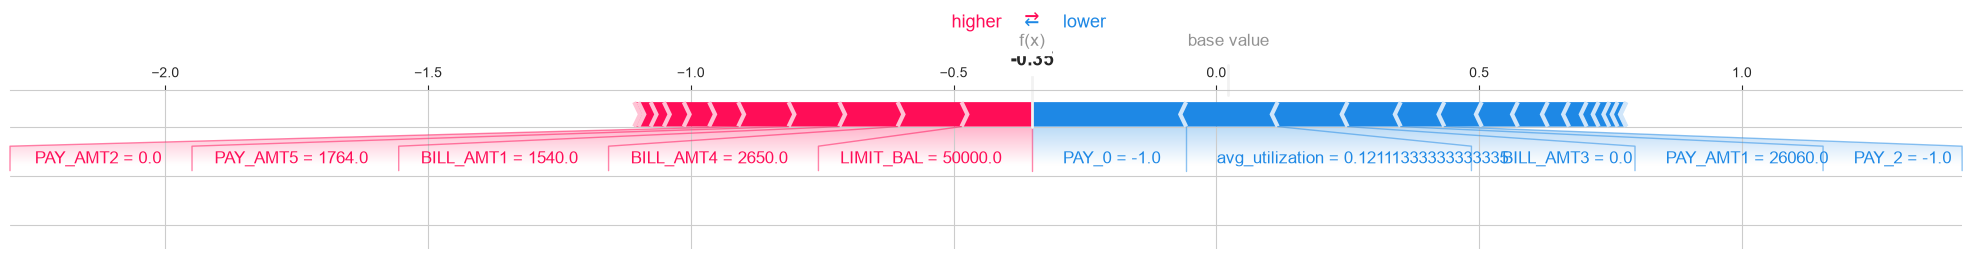

In [13]:
sample_idx = 0
shap.force_plot(
    explainer.expected_value, shap_values[sample_idx], X_test.iloc[sample_idx],
    matplotlib=True, show=False
)
plt.tight_layout()
plt.savefig('../docs/shap_individual_example.png', dpi=150)
plt.show()

## Fairness check

Default rate and false-positive rate across `SEX` and `AGE` groups, using the
XGBoost predictions on the test set. `SEX`: 1 = male, 2 = female (per the UCI
data dictionary). Age is bucketed into ranges for a readable comparison.

In [14]:
fairness_df = X_test.copy()
fairness_df['y_true'] = y_test.values
fairness_df['y_pred'] = xgb_pred
fairness_df['sex_label'] = fairness_df['SEX'].map({1: 'male', 2: 'female'})
fairness_df['age_bucket'] = pd.cut(
    fairness_df['AGE'], bins=[20, 30, 40, 50, 60, 80],
    labels=['21-30', '31-40', '41-50', '51-60', '61+']
)

def group_fairness_metrics(frame, group_col):
    rows = []
    for group, g in frame.groupby(group_col, observed=True):
        tn, fp, fn, tp = confusion_matrix(g['y_true'], g['y_pred'], labels=[0, 1]).ravel()
        rows.append({
            'group': group,
            'n': len(g),
            'actual_default_rate': g['y_true'].mean(),
            'predicted_default_rate': g['y_pred'].mean(),
            'false_positive_rate': fp / (fp + tn) if (fp + tn) else np.nan,
            'false_negative_rate': fn / (fn + tp) if (fn + tp) else np.nan,
        })
    return pd.DataFrame(rows)

sex_fairness = group_fairness_metrics(fairness_df, 'sex_label')
age_fairness = group_fairness_metrics(fairness_df, 'age_bucket')
sex_fairness

,group,n,actual_default_rate,predicted_default_rate,false_positive_rate,false_negative_rate
0,female,3598,0.212896,0.265703,0.171963,0.387728
1,male,2402,0.233555,0.317236,0.225964,0.383244


In [15]:
age_fairness

,group,n,actual_default_rate,predicted_default_rate,false_positive_rate,false_negative_rate
0,21-30,2181,0.219624,0.290234,0.189189,0.350731
1,31-40,2105,0.209501,0.270784,0.186298,0.410431
2,41-50,1243,0.234916,0.286404,0.196635,0.421233
3,51-60,413,0.244552,0.334140,0.233974,0.356436
4,61+,58,0.241379,0.362069,0.250000,0.285714


In [16]:
sex_fairness.to_csv('../docs/fairness_by_sex.csv', index=False)
age_fairness.to_csv('../docs/fairness_by_age.csv', index=False)

## Save trained model

In [17]:
import joblib
joblib.dump(xgb, '../models/xgb_model.joblib')
joblib.dump(list(X_train.columns), '../models/feature_columns.joblib')
print('saved model and feature list')

saved model and feature list
